# RAG向量数据库
## VectorStore存储组件
### VectorStore组件介绍
对非结构化数据的存储与检索，最常用的方法是先将文本进行嵌入，转换为向量后存储到向量数据库中；在查询时，同样将查询文本嵌入生成向量，再将该向量传递给向量数据库，由数据库完成后续的相似度计算与检索过程。

在 LangChain 中，这一过程由顶层接口 VectorStore 统一管理，不同类型的向量数据库只需实现该接口中的抽象方法即可完成集成。VectorStore 接口提供了多个常用方法，例如：

- add_texts：将文本列表转换为向量，并存储到向量数据库。
- add_documents：将文档列表转换为向量，并存储到向量数据库。
- as_retriever：返回向量数据库初始化的检索器。
- similarity_search_with_relevance_scores：进行相似性检索，返回文档及其相关性得分（范围在[0, 1]之间）。
- delete：根据向量id删除向量数据
- from_texts：传入文本列表、元数据信息、文本嵌入模型，返回创建好的VectorStore。

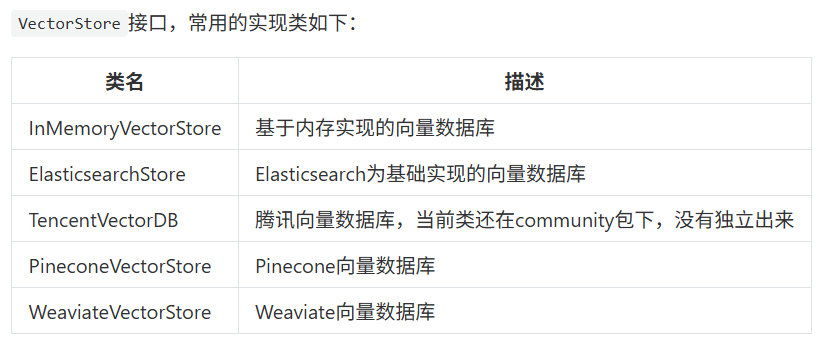

### RedisVectorStore数据存储

RedisVectorStore是 VectorStore 接口的一个实现类，下面将以它为例介绍 VectorStore 的用法。在使用 WeaviateVectorStore 之前，需要先安装 langchain-redis 依赖：

In [1]:
%pip install langchain-redis

Looking in indexes: https://pypi.tuna.tsinghua.edu.cn/simple
     ---------------------------------------- 0.0/2.9 MB ? eta -:--:--
     -------------- ------------------------- 1.0/2.9 MB 5.6 MB/s eta 0:00:01
     ---------------------------------------- 2.9/2.9 MB 9.4 MB/s  0:00:00
  Attempting uninstall: hf-xet
    Found existing installation: hf-xet 1.5.0
    Uninstalling hf-xet-1.5.0:
      Successfully uninstalled hf-xet-1.5.0
Note: you may need to restart the kernel to use updated packages.


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.14.0 requires hf-xet<2.0.0,>=1.4.3; platform_machine == "x86_64" or platform_machine == "amd64" or platform_machine == "AMD64" or platform_machine == "arm64" or platform_machine == "aarch64", but you have hf-xet 1.2.0 which is incompatible.


接下来，先展示如何Ollama Embedding 转为词向量后使用 RedisVectorStore 进行数据存储，示例程序如下

In [3]:
from langchain_ollama import OllamaEmbeddings
from langchain_redis import RedisConfig, RedisVectorStore
import dotenv
from langchain_community.embeddings import DashScopeEmbeddings
import os
# 读取env配置
dotenv.load_dotenv()
qwen_api_key = os.getenv("QWEN_API_KEY")
#（在线调用）初始化嵌入模型，用于将文本转换为向量表示
embedding = DashScopeEmbeddings(
    model="text-embedding-v2",
    dashscope_api_key=qwen_api_key
)

# ========== 存储数据 ==========
# 定义待处理的文本数据列表
texts = [
    "我喜欢吃苹果",
    "苹果是我最喜欢吃的水果",
    "我喜欢用苹果手机",
]

# 获取文本向量
# 使用embedding模型将文本转换为向量表示

embeddings = embedding.embed_documents(texts)

# 打印结果
# 遍历并打印每个文本及其对应的向量信息
for i, vec in enumerate(embeddings, 1):
    print(f"文本 {i}: {texts[i-1]}")
    print(f"向量长度: {len(vec)}")
    print(f"前5个向量值: {vec[:10]}\n")

# 定义每条文本对应的元数据信息
metadata = [{"segment_id": "1"}, {"segment_id": "2"}, {"segment_id": "3"}]

# 配置Redis连接参数和索引名称
config = RedisConfig(
    index_name="newsgroups",
    redis_url="redis://localhost:6379",
)

# 创建Redis向量存储实例
vector_store = RedisVectorStore(embedding, config=config)

# 将文本和元数据添加到向量存储中
ids = vector_store.add_texts(texts, metadata)

# 打印前5个存储记录的ID
print(ids[0:5])

文本 1: 我喜欢吃苹果
向量长度: 1536
前5个向量值: [0.007528396693603428, 0.015152772946647219, 0.056244021832052384, -0.021343454530550594, -0.014492913475494727, -0.0068325448876608, -0.02061161038981783, -0.01122360973205738, 0.01742029003842578, 0.008452199953216916]

文本 2: 苹果是我最喜欢吃的水果
向量长度: 1536
前5个向量值: [-0.001018792109526149, 0.040506824474893746, 0.03796494544912321, 0.01891251275137526, 0.006517937501861142, 0.006133157649336244, -0.0304792283181843, -0.01192817542827182, 0.02492907044540093, 0.010837965846117945]

文本 3: 我喜欢用苹果手机
向量长度: 1536
前5个向量值: [-0.004440249583827072, 0.016683473555592927, 0.04402112470837147, -0.03322166287122423, -0.03065497463190224, -0.009237656257559798, -0.0021520228044315257, -0.0010260699447289553, -0.005042573828667963, 0.018729559935052435]

['newsgroups:01KRN1RNCCS7AMTNYCXBXJRRE0', 'newsgroups:01KRN1RNCCS7AMTNYCXBXJRRE1', 'newsgroups:01KRN1RNCCS7AMTNYCXBXJRRE2']


### RedisVectorStore数据检索

在上面的示例程序中，我们将文本信息和元数据信息都保存到了数据库中。接下来，使用 VectorStore的similarity_search_with_relevance_scores() 方法进行相似性检索。在调用该方法时，传入查询文本 query，并指定 k=3，即返回匹配分数最高的三条数据（k 的默认值为 4）。

In [4]:
from langchain_ollama import OllamaEmbeddings
from langchain_redis import RedisConfig, RedisVectorStore
import dotenv
from langchain_community.embeddings import DashScopeEmbeddings
import os
# 读取env配置
dotenv.load_dotenv()
qwen_api_key = os.getenv("QWEN_API_KEY")
#（在线调用）初始化嵌入模型，用于将文本转换为向量表示
embedding = DashScopeEmbeddings(
    model="text-embedding-v2",
    dashscope_api_key=qwen_api_key
)

# 配置Redis连接参数和索引名称
config = RedisConfig(
    index_name="newsgroups",
    redis_url="redis://localhost:6379",
)

# 创建Redis向量存储实例
vector_store = RedisVectorStore(embedding, config=config)


# ========== 查询数据 ==========
# 定义查询文本
query = "我喜欢用什么手机"

# 将查询语句向量化，并在Redis中做相似度检索
results = vector_store.similarity_search_with_score(query, k=3)

print("=== 查询结果 ===")
for i, (doc, score) in enumerate(results, 1):
    similarity = 1 - score  #  score 是距离，可以转成相似度
    print(f"结果 {i}:")
    print(f"内容: {doc.page_content}")
    print(f"元数据: {doc.metadata}")
    print(f"相似度: {similarity:.4f}")


=== 查询结果 ===
结果 1:
内容: 我喜欢用苹果手机
元数据: {'segment_id': '3'}
相似度: 0.6703
结果 2:
内容: 我喜欢吃苹果
元数据: {'segment_id': '1'}
相似度: 0.4403
结果 3:
内容: 苹果是我最喜欢吃的水果
元数据: {'segment_id': '2'}
相似度: 0.3787


## Retrievers检索器组件
### VectorStoreRetriever使用
在 RAG 应用中，当需要基于向量数据库进行文档检索时，就可以使用VectorStoreRetriever。它封装了向量数据库检索的底层逻辑，能够直接调用 VectorStore 的方法，从向量数据库中检索最相关的文档。

在前面介绍 VectorStore 常用方法时，包括了 as_retriever() 方法，该方法可以构建一个检索器对象，这个检索器就是 VectorStoreRetriever。

使用示例如下，使用as_retriever()方法创建了一个VectorStoreRetriever 对象，之后调用invoke()方法传入query进行文档检索。

In [5]:
from langchain_ollama import OllamaEmbeddings
from langchain_redis import RedisConfig, RedisVectorStore
import dotenv

# 读取env配置
dotenv.load_dotenv()

#（在线调用）初始化嵌入模型，用于将文本转换为向量表示
embedding = DashScopeEmbeddings(
    model="text-embedding-v2",
    dashscope_api_key=qwen_api_key
)

# 配置Redis连接参数和索引名称
config = RedisConfig(
    index_name="newsgroups",
    redis_url="redis://localhost:6379",
)

# 创建Redis向量存储实例
vector_store = RedisVectorStore(embedding, config=config)


# 创建检索器，进行数据检索
retriever = vector_store.as_retriever()
documents = retriever.invoke("介绍一下我喜欢用什么手机")

for document in documents:
    print(document.page_content)
    print(document.metadata)
    print("=================================")

我喜欢用苹果手机
{'segment_id': '3'}
我喜欢吃苹果
{'segment_id': '1'}
苹果是我最喜欢吃的水果
{'segment_id': '2'}


### MultiQueryRetriever使用
在向量检索过程中，查询文本会被转换为向量，并通过计算向量间距离来检索相似文档。然而，检索结果的准确性可能会受到查询文本表达方式的影响。

因此，为了提升查询结果的准确性，可以将查询文本传递给大语言模型，由其生成多个不同表达方式的查询文本变体。随后，使用这些不同的查询文本分别进行文档检索，并将所有检索结果汇总、排序，返回最相关的文档。

MultiQueryRetriever（多查询检索器）正是实现上述 RAG 检索优化逻辑的工具。可以使用 MultiQueryRetriever.from_llm() 方法创建一个多查询检索器。进入 from_llm() 源码可以看到，除了需要传递检索器对象和模型对象之外，还可以传入 prompt 参数，该参数用于调用大模型生成多个查询文本的提示词，并提供了默认值。

In [ ]:
from langchain_classic.retrievers import MultiQueryRetriever
from langchain_core.prompts import PromptTemplate
from langchain_deepseek import ChatDeepSeek
from langchain_redis import RedisConfig, RedisVectorStore
import dotenv
import os

# 读取env配置
dotenv.load_dotenv()

#（在线调用）初始化嵌入模型，用于将文本转换为向量表示
embedding = DashScopeEmbeddings(
    model="text-embedding-v2",
    dashscope_api_key=qwen_api_key
)
# 初始化 DeepSeek 大语言模型
llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=os.getenv("DEEPSEEK_API_KEY")
)
# 配置Redis连接参数和索引名称
config = RedisConfig(
    index_name="newsgroups",
    redis_url="redis://localhost:6379",
)

# 创建Redis向量存储实例
vector_store = RedisVectorStore(embedding, config=config)

# 创建多查询检索器
retriever = vector_store.as_retriever()
retriever_from_llm = MultiQueryRetriever.from_llm(
    retriever=retriever, llm=llm,
    prompt=PromptTemplate(
        input_variables=["question"],
        template="""你是一个 AI 语言模型助手。你的任务是：
        为给定的用户问题生成 3 个不同的版本，以便从向量数据库中检索相关文档。
        通过生成用户问题的多种视角（改写版本），
        你的目标是帮助用户克服基于距离的相似性搜索的某些局限性。
        请将这些改写后的问题用换行符分隔开。原始问题：{question}""")
)

# 5.进行数据检索
documents = retriever_from_llm.invoke("介绍一下我喜欢使用的手机")

for document in documents:
    print(document.page_content)
    print(document.metadata)
    print("=================================")


我喜欢用苹果手机
{'segment_id': '3'}
我喜欢吃苹果
{'segment_id': '1'}
苹果是我最喜欢吃的水果
{'segment_id': '2'}


自定义检索器实现

实现一个自定义检索器需要继承 BaseRetriever 并实现 _get_relevant_documents 方法。

假设有如下需求：需要一个自定义检索器，将传入的查询文本按空格拆分成关键词数组，并在文档中进行匹配。只要有任意一个关键词匹配成功，即返回该文档信息，同时支持通过传递参数控制检索器返回的文档数量。

具体实现该需求的代码示例如下：

In [21]:
from typing import List

from langchain_core.callbacks import CallbackManagerForRetrieverRun
from langchain_core.documents import Document
from langchain_core.retrievers import BaseRetriever


class KeywordsRetriever(BaseRetriever):
    """自定义检索器
    
    该检索器根据查询中的关键词来检索相关文档，支持返回前k个匹配的文档
    
    Attributes:
        documents: 文档列表，用于检索的文档集合
        k: 返回文档数量，指定最多返回多少个相关文档
    """
    documents: List[Document]
    k: int

    def _get_relevant_documents(self, query: str, *, run_manager: CallbackManagerForRetrieverRun) -> List[Document]:
        """根据查询关键词检索相关文档
        
        Args:
            query: 查询字符串，将被拆分为多个关键词进行匹配
            run_manager: 回调管理器，用于处理检索过程中的回调
            
        Returns:
            List[Document]: 包含匹配文档的列表，最多返回k个文档
        """
        # 获取返回文档数量参数
        k = self.k if self.k is not None else 3
        documents_result = []

        # 将查询字符串按空格拆分为关键词列表
        query_keywords = query.split(" ")

        # 遍历所有文档，筛选包含任一关键词的文档
        for document in self.documents:
            if any(query_keyword in document.page_content for query_keyword in query_keywords):
                documents_result.append(document)

        # 返回前k个匹配的文档
        return documents_result[:k]


# 定义文档列表，包含用于检索的文本内容
documents = [
    Document("苹果是我最喜欢吃的水果"),
    Document("我喜欢吃苹果"),
    Document("我喜欢用苹果手机"),
]

# 创建关键词检索器实例，设置文档集合和返回文档数量
retriever = KeywordsRetriever(documents=documents, k=1)

# 执行检索操作，根据查询"手机"查找相关文档
result = retriever.invoke("手机")

# 输出检索结果，打印匹配文档的内容
for document in result:
    print(document.page_content)
    print("===========================")


我喜欢用苹果手机
